In [51]:
import torch
import torch.nn as nn # NN means neural network
import torch.nn.functional as F # would help us move our data forward and backward through the network.
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

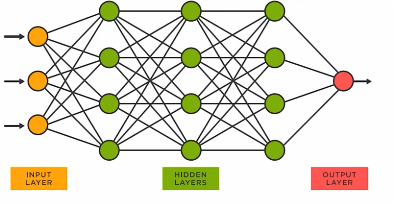

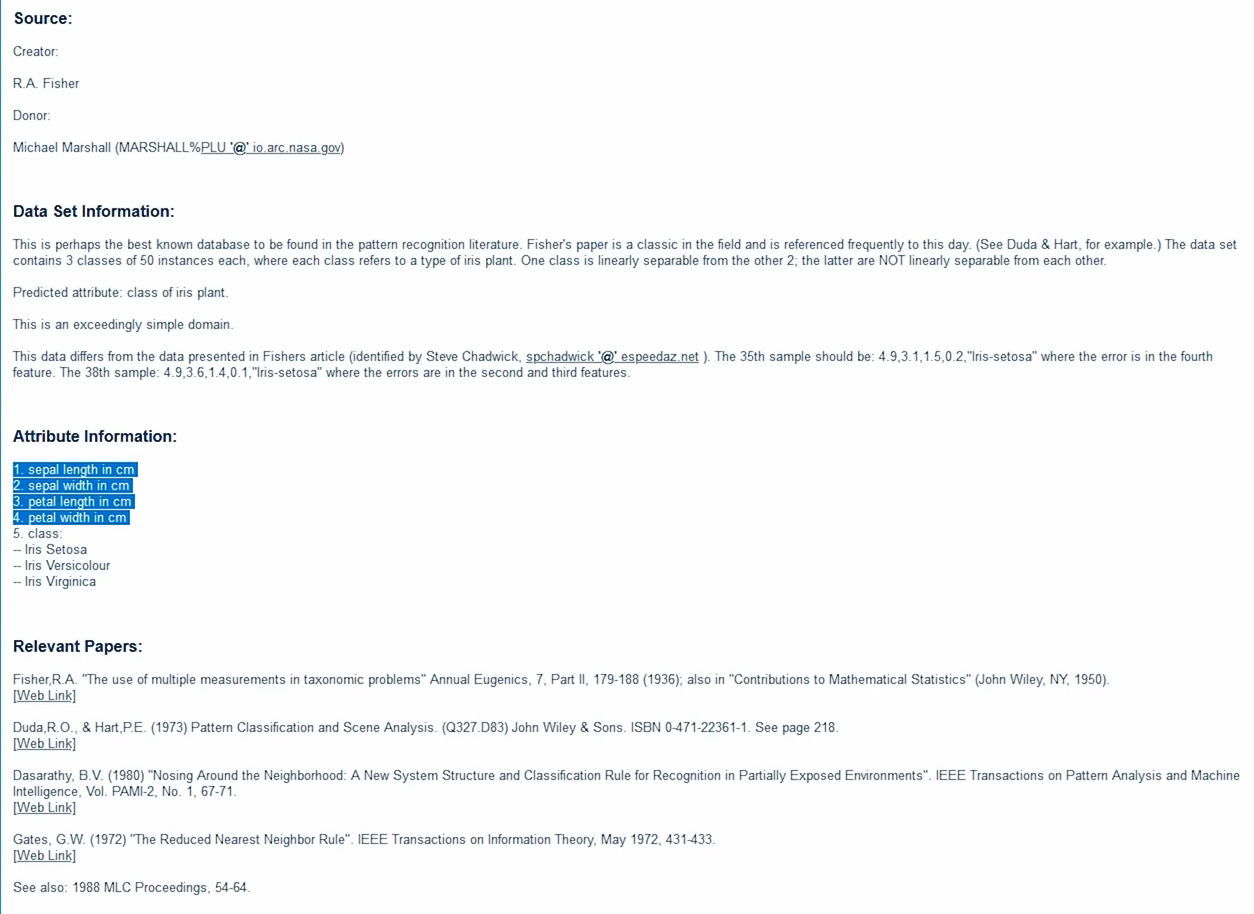

In [52]:
# create a class that inherits from nn.Module
# 1. sepal length in cm
# 2. sepal width in cm
# 3. petal length in cm
# 4. petal width in cm
# 5. class:
# -- Iris Setosa
# -- Iris Versicolour
# -- Iris Virginica

class Model(nn.Module):
    # Input layer(4 feutures of the flower) -> 
    # Hidden layer1 (number of neurons) -> 
    # H2(n) -> 
    # output (3 classes of iris flowers) 
    # -- Iris Setosa
    # -- Iris Versicolour
    # -- Iris Virginica
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__() # inherit the nn.module
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x

       

In [53]:
# pick a muanual seed for randomization
torch.manual_seed(35)

# create an instance of our model

model = Model()

In [54]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

my_df.head(10)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


In [55]:
# data cleaning
# change last column to indexed numbers from strings to integer
my_df['variety'] = my_df['variety'].replace('Setosa', 0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1)
my_df['variety'] = my_df['variety'].replace('Virginica', 2)

#.replace() returns a new Series
# you are assigning it back to the DataFrame column

my_df

C:\Users\User\AppData\Local\Temp\ipykernel_14944\3849134875.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [56]:
# train test and split
# set X and y

X = my_df.drop('variety', axis=1) # axis 1 means drop the column, axis 0 means drop the row
y = my_df['variety']



In [57]:
#convert to numpy arrays 
X = X.values 
y = y.values

print(X)
print(y)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [58]:
# train split test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42) # test size is 20% of the data, train size is 80% of the data


# What each argument means
# 1. X
# Your input features
# Example: sepal length, sepal width, etc.

# 2. y
# Your labels (answers)
# Example: Setosa / Versicolor / Virginica

# 3. test_size=0.2
# Means: 20% of data goes to testing
# So if you have 100 samples:
# 80 → training set
# 20 → test set

# 4. random_state=42
# Makes the split reproducible
# Without it:
# every run gives a different split
# With it:
# you always get the same split
# Think of it like a “seed” for randomness.


In [59]:
# covert the x features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [60]:
# convert the y labels to long tensors (integers)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [ ]:
# set the criterion of model to measure the error, how far off the predictions are from the data

criterion = nn.CrossEntropyLoss() # good for multi-class classification problems

# choose Adam optimizer, learning rate = 0.001
# ( if error doesnt go down after a bunch of iterations(epochs) )
# lower our learning rate

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model.parameters
model.parameters
# model.parameters() works because PyTorch automatically tracks every 
# layer you define inside nn.Module.

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [ ]:
# train our model
# how many epochs (iterations) do we want to train for?( one run through the entire network)
epochs = 100
losses = []

for i in range(epochs):
    # go forward and get the predictions
    y_pred = model.forward(X_train) # get predicted results
    
    # measure the loss/ gonna be high at first
    
    loss = criterion(y_pred, y_train) # compare predicted results to actual labels
    
    # Go forward and get a prediction

    loss = criterion(y_pred, y_train) # predicted values vs the y_train

    # Keep Track of our losses
    losses.append(loss.detach().numpy())

    # print every 10 epoch
    if i % 10 == 0:
        print(f'Epoch: {i} and loss: {loss}')

    # Do some back propagation: take the error rate of forward propagation and feed it back
    # thru the network to fine tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
        
    
    

Epoch: 0 and loss: 1.1674495935440063
Epoch: 10 and loss: 1.1130201816558838
Epoch: 20 and loss: 1.0748674869537354
Epoch: 30 and loss: 1.0510283708572388
Epoch: 40 and loss: 1.0335928201675415
Epoch: 50 and loss: 1.0158158540725708
Epoch: 60 and loss: 0.9967994093894958
Epoch: 70 and loss: 0.9754660725593567
Epoch: 80 and loss: 0.9515416622161865
Epoch: 90 and loss: 0.9246378540992737
